# Amass to Motor Representation

## SMPL model

In [10]:
import numpy as np
smpl = np.load('../serialized/model.npz')
bone_vertices = smpl['J'][:22]
kinematic_child_parent_full = list(enumerate(smpl['kintree_table'][0][1:], start=1))
kinematic_child_parent = list(enumerate(smpl['kintree_table'][0][1:22], start=1))
np.save('kinematic_child_parent.npy', kinematic_child_parent)
# mesh_triangle_faces = smpl['f']

In [11]:
# default mesh of smpl adapt to 22 joints in amass
mesh_vertices = smpl['v_template']
vertex_weights_52 = smpl['weights']
vertex_weights_22 = vertex_weights_52.copy()
for child, parent in kinematic_child_parent_full:
    if child > 21:
        vertex_weights_22[:, parent] += vertex_weights_52[:, child]
vertex_weights = vertex_weights_22[:, :22].copy()
del vertex_weights_22, vertex_weights_52, kinematic_child_parent_full

In [12]:
from kingdon import Algebra

def label_bones(bones):    
    bone_with_label = []
    num_str = list(map(str, range(len(bones))))
    for b, n in zip(bones, num_str):
        bone_with_label.append(b)
        bone_with_label.append(n)
    return bone_with_label

def bone_pairs(points):
    return [[points[parent], points[child]] for child, parent in kinematic_child_parent]

def xyz_to_point(v):
    x,y,z = v
    return (e0 + x * e1 + y * e2 + z * e3).dual()

alg = Algebra(3, 0, 1)
locals().update(alg.blades)
mesh_points = [xyz_to_point(v) for v in mesh_vertices]
del mesh_vertices
bone_points = [xyz_to_point(v) for v in bone_vertices]

# triangles = [[mesh_points[i] for i in row] for row in mesh_triangle_faces]

alg.graph(
    0x555555, *mesh_points[::20],
    0x557722, *label_bones(bone_points),
    0x557722, *bone_pairs(bone_points),
    grid=True, labels=True, pointRadius=0.2
)

In [13]:
def trp(p0, p1):
    """ Translate from p0 to p1. """
    line = p0 & p1
    return ((0.5 * e0) ^ (line | e123)).exp()

trp(bone_points[0], bone_points[1]) >> bone_points[0], bone_points[1]

(-0.0198 𝐞₀₁₂ + -0.301 𝐞₀₁₃ + -0.0705 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0198 𝐞₀₁₂ + -0.301 𝐞₀₁₃ + -0.0705 𝐞₀₂₃ + 1 𝐞₁₂₃)

In [14]:
# Translate along kinematic chain from the root point
# But to have a body-frame-view, we want to translate from the origin
station_joint_translation = [1+0*e01+0*e02 + 0*e03]
for child, parent in kinematic_child_parent:
    if child >= 22:
        break
    station_joint_translation.append(trp(bone_points[parent], bone_points[child]))
# serialize for data processing
np.save('station_joint_translation.npy', [t.values() for t in station_joint_translation])


full_motors = station_joint_translation.copy()
for child, parent in kinematic_child_parent:
    if child >= 22:
        break
    if parent > 0:
        # If only translations, the parent-child order doesn't matter
        full_motors[child] = full_motors[parent] * full_motors[child]

moved_points = [r >> bone_points[0] for r in full_motors]
# moved_points = [r >> e123 for r in full_motors]

alg.graph(
    0x555555, *moved_points,
    0x557722, *bone_points,
    grid=True, labels=True, pointRadius=0.5
)

In [15]:
# We can do the above in reverse, to shift back each bone points to the root point
[~r >> bone_point for r, bone_point in zip(full_motors, bone_points)]

[-0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ + 0.000876 𝐞₀₂₃ + 1 𝐞₁₂₃,
 -0.0278 𝐞₀₁₂ + -0.211 𝐞₀₁₃ 

In [16]:
# We shift back the mesh points along the "bones to origin"-translations
# So the mesh fits our motor blending for each pose
mesh_to_origin = []
root_to_origin = trp(bone_points[0], e123)
for i, p in enumerate(mesh_points):
    blended_motor = sum(w * m for w, m in zip(vertex_weights[i], full_motors))
    deformed = root_to_origin >> (~blended_motor >> p)
    mesh_to_origin.append(deformed)

alg.graph(
    0x555555, *mesh_to_origin[::10],
    grid=True, labels=True, pointRadius=0.2
)

## Axis-Angle Poses

In [17]:
motion = np.load('../serialized/05_07_poses.npz')
# motion = np.load('motions/wave_right03_poses.npz')
root_orient = motion['poses'][:, :3] # 1 root joint
pose_body = motion['poses'][:, 3:66] # 21 child joints
root_trans = motion['trans']

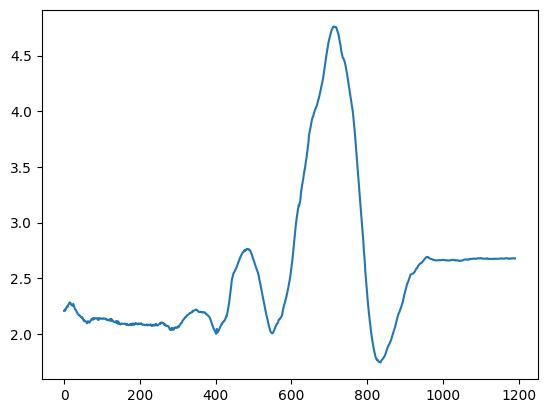

In [18]:
import matplotlib.pyplot as plt
plt.plot(np.linalg.norm(root_orient, axis=1))

In [19]:
max(np.linalg.norm(root_orient[1:] - root_orient[:-1], axis=1)), np.mean(np.linalg.norm(root_orient[1:] - root_orient[:-1], axis=1)), 

(0.22511899530845098, 0.02645130483509148)

In [20]:
np.argmax(np.linalg.norm(root_orient[1:] - root_orient[:-1], axis=1))

722

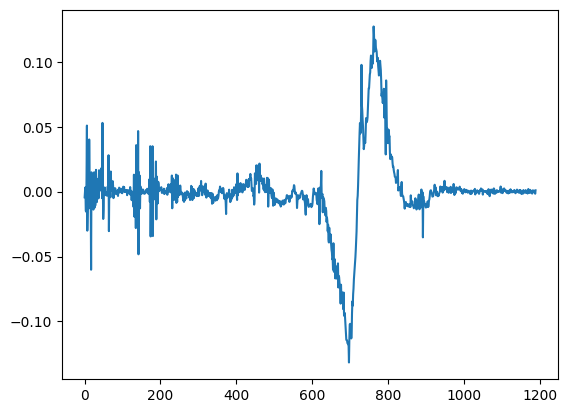

In [21]:
o_diff = root_orient[1:] - root_orient[:-1]
plt.plot(o_diff[:, 0])

In [22]:
root_orient[0], root_orient[690], root_orient[722],root_orient[750], root_orient[-1]

(array([1.39506347, 1.33244024, 1.07218427]),
 array([-2.15714706,  3.63622962,  1.39665389]),
 array([-4.71230044,  0.01599608, -0.04422957]),
 array([-3.28966461, -2.24111064, -1.50983201]),
 array([1.21117983, 1.92861302, 1.40740802]))

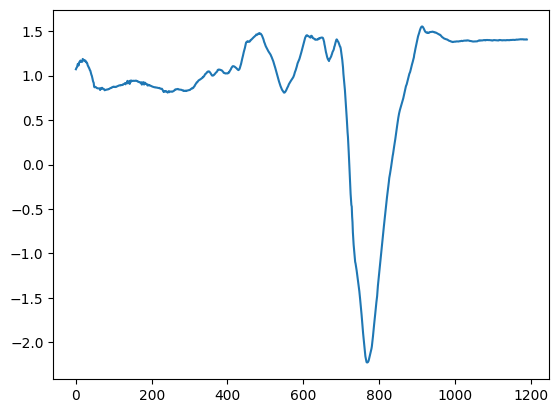

In [23]:
plt.plot(root_orient[:, 2])

In [24]:
thetas = np.linalg.norm(root_orient, axis=1)
max(thetas) - min(thetas)

3.0178558479652215

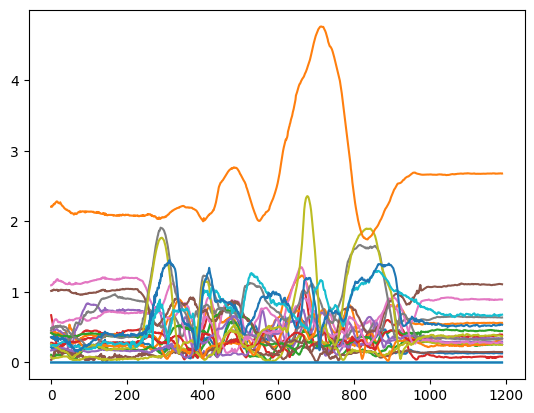

In [25]:
plt.plot(np.linalg.norm(pose_body.reshape(1191, -1, 3), axis=2))
plt.plot(np.linalg.norm(root_orient, axis=1))

In [26]:
def expmap_to_quaternion(e):
    """
    Convert axis-angle rotations (aka exponential maps) to quaternions.
    Stable formula from "Practical Parameterization of Rotations Using the Exponential Map".
    Expects a tensor of shape (*, 3), where * denotes any number of dimensions.
    Returns a tensor of shape (*, 4).
    """
    assert e.shape[-1] == 3

    original_shape = list(e.shape)
    original_shape[-1] = 4
    e = e.reshape(-1, 3)

    theta = np.linalg.norm(e, axis=1).reshape(-1, 1)
    w = np.cos(0.5 * theta).reshape(-1, 1)
    xyz = 0.5 * np.sinc(0.5 * theta / np.pi) * e
    return np.concatenate((w, xyz), axis=1).reshape(original_shape)

def qfix(q):
    """
    Enforce quaternion continuity across the time dimension by selecting
    the representation (q or -q) with minimal distance (or, equivalently, maximal dot product)
    between two consecutive frames.

    Expects a tensor of shape (L, J, 4), where L is the sequence length and J is the number of joints.
    Returns a tensor of the same shape.
    """
    # assert len(q.shape) == 3
    assert q.shape[-1] == 4
    dot_products = np.sum(q[1:] * q[:-1], axis=1)
    mask = dot_products < 0
    num_flip = np.sum(mask)
    if num_flip:
        print(f'with {num_flip} sign flips')
        result = q.copy()
        mask = (np.cumsum(mask, axis=0) % 2).astype(bool)
        result[1:][mask] *= -1
        return result
    return q

quat_root_orient = expmap_to_quaternion(root_orient)
quat_root_orient = qfix(quat_root_orient)

In [27]:
q = expmap_to_quaternion(root_orient)
q[1:] * q[:-1]

array([[0.20271935, 0.31742095, 0.28976124, 0.19008533],
       [0.20020051, 0.31567462, 0.29122476, 0.19287561],
       [0.19955902, 0.31625101, 0.28899658, 0.1951442 ],
       ...,
       [0.05254876, 0.19375718, 0.49226422, 0.26142967],
       [0.05288273, 0.1937277 , 0.49132106, 0.26206678],
       [0.05305341, 0.19371296, 0.49106491, 0.26216806]])

In [28]:
pose_body.shape

(1191, 63)

In [29]:
q = pose_body.reshape(1191, -1, 3)
dot_products = np.sum(q[1:] * q[:-1], axis=2)
mask = dot_products < 0
np.sum(mask), mask.shape

(0, (1190, 21))

In [30]:
q.shape

(1191, 21, 3)

In [31]:
axis_angles = pose_body[0].reshape(-1, 3)
def axis_angle_to_rotor(axis_angle, bone_index):
    theta = np.linalg.norm(axis_angle)
    B = e123 & xyz_to_point(axis_angle)
    rotator = np.cos(theta/2) + 0.5*np.sinc(0.5 * theta / np.pi) * B
    translator = station_joint_translation[bone_index+1]
    return rotator * translator
axis_angle_to_rotor(axis_angles[0], 0)

0.994 + -0.0352 𝐞₀₁ + 0.0444 𝐞₀₂ + 0.00784 𝐞₀₃ + 0.00902 𝐞₁₂ + -0.0238 𝐞₁₃ + -0.105 𝐞₂₃ + 0.00484 𝐞₀₁₂₃

In [ ]:
# I thought the parent motor acts before childs
# But then we have to do a reverse, and a point reflection to retain the correct pose.
axis_angles = pose_body[200].reshape(-1, 3)
rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
full_motors = rotors.copy()
for child, parent in kinematic_child_parent:
    if child >= 22:
        break
    if parent > 0:
        full_motors[child] = full_motors[child] * full_motors[parent]

moved_points = [(e123*(~r) )>> e123 for r in full_motors]

alg.graph(
    0x555555, *bone_pairs(moved_points),
    # 0x557722, *bone_with_label
    grid=True, labels=True, pointRadius=0.5
)

In [ ]:
# So the composition of transformations in terms of motors are children to parents!
# Perfectly reasonable if we view from the joint's body frame

def axis_angle_to_rotor(axis_angle, bone_index):
    theta = np.linalg.norm(axis_angle)
    B = xyz_to_point(axis_angle) & e123
    rotator = np.cos(theta/2) + 0.5*np.sinc(0.5 * theta / np.pi) * B
    translator = station_joint_translation[bone_index+1]
    return translator * rotator


axis_angles = pose_body[200].reshape(-1, 3)
rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
full_motors = rotors.copy()
for child, parent in kinematic_child_parent:
    if child >= 22:
        break
    if parent > 0:
        # Note that the child operators act before parents on the origin
        full_motors[child] = full_motors[parent] * full_motors[child]

moved_points = [(r)>> e123 for r in full_motors]

alg.graph(
    0x555555, *bone_pairs(moved_points),
    # 0x557722, *bone_with_label
    grid=True, labels=True, pointRadius=0.5
)

In [34]:
moved_mesh_points = []
for i, p in enumerate(mesh_to_origin):
    if not (i % 10):
        blended_motor = sum(w * m for w, m in zip(vertex_weights[i], full_motors))
        deformed = ((blended_motor) >> p)
        moved_mesh_points.append(deformed)
alg.graph(
    # 0x555555, *bone_pairs(moved_points),
    0x557722, *moved_mesh_points,
    grid=True, labels=True, pointRadius=0.2
)

In [ ]:
# So the composition of transformations in terms of motors are children to parents!

def axis_angle_to_rotor(axis_angle, bone_index):
    theta = np.linalg.norm(axis_angle)
    B = xyz_to_point(axis_angle) & e123
    rotator = np.cos(theta/2) + 0.5*np.sinc(0.5 * theta / np.pi) * B
    translator = station_joint_translation[bone_index+1]
    return translator * rotator


axis_angles = pose_body[200].reshape(-1, 3)
rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
full_motors = rotors.copy()
for child, parent in kinematic_child_parent:
    if child >= 22:
        break
    if parent > 0:
        # Note that the child operators act before parents on the origin
        full_motors[child] = full_motors[parent] * full_motors[child]

moved_points = [(r)>> e123 for r in full_motors]

alg.graph(
    0x555555, *bone_pairs(moved_points),
    # 0x557722, *bone_with_label
    grid=True, labels=True, pointRadius=0.5
)

In [36]:
# floor as a plane/motor
def root_to_motor(orient, trans):
    theta = np.linalg.norm(orient)
    B = xyz_to_point(orient) & e123
    rotator = np.cos(theta/2) + 0.5*np.sinc(0.5 * theta / np.pi) * B
    translator = trp(e123, xyz_to_point(trans))
    return translator * rotator

def root_to_rot_motor(orient, trans):
    theta = np.linalg.norm(orient)
    B = xyz_to_point(orient) & e123
    rotator = np.cos(theta/2) + 0.5*np.sinc(0.5 * theta / np.pi) * B
    return rotator

root_motors = [root_to_motor(o,t) for o, t in zip(root_orient, root_trans)]
root_rot_motors = [root_to_rot_motor(o,t) for o, t in zip(root_orient, root_trans)]
root_body_rot_motors = [~root_rot_motors[0] * r for r in root_rot_motors]

floors = [~r >> e3 for r in root_motors]
root_body_motors = [~r * root_motors[0] for r in root_motors]
root_trajectory = [r >> e123 for r in root_body_motors]

In [37]:
# naive inverse kinematics by shifting as much movement to the child joints as possible
chained_motors = root_bod

NameError: name 'root_bod' is not defined

In [38]:
frame = 1000
axis_angles = pose_body[frame].reshape(-1, 3)
rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
full_motors = rotors.copy()
for child, parent in kinematic_child_parent:
    if child >= 22:
        break
    if parent > 0:
        # Note that the child operators act before parents on the origin
        full_motors[child] = full_motors[parent] * full_motors[child]

moved_mesh_points = []
for i, p in enumerate(mesh_to_origin):
    if not (i % 10):
        blended_motor = sum(w * m for w, m in zip(vertex_weights[i], full_motors))
        deformed = ((blended_motor) >> p)
        moved_mesh_points.append(deformed)

alg.graph(
    0x555555, floors[frame],
    0x773355, *root_trajectory[:frame],
    0x557722, *moved_mesh_points,
    grid=True, labels=True, pointRadius=0.2
)

In [39]:
# PGA make left-right-swap simple
alg.graph(
    0x555555, e1,
    0x773355, *[e1 >> p for p in root_trajectory[:frame]],
    0x557722, *[e1 >> p for p in moved_mesh_points],
    grid=True, labels=True, pointRadius=0.2
)

In [40]:
# projection of the trajectory onto the floor
alg.graph(
    0x555555, floors[frame],
    0x773355, *[p.rc(floors[frame]) * floors[frame] for p in root_trajectory[:frame]],
    0x557722, *moved_mesh_points,
    grid=True, labels=True, pointRadius=0.2
)

In [41]:
# If we randomize each motor
median = np.median(pose_body, axis=0)
std = np.std(pose_body, axis=0)
random_axis_angles = np.random.normal(loc=median, scale=3*std).reshape(-1, 3)
random_rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(random_axis_angles)]
full_motors = random_rotors.copy()
for child, parent in kinematic_child_parent:
    if child >= 22:
        break
    if parent > 0:
        full_motors[child] = full_motors[parent] * full_motors[child]

moved_points = [(r)>> e123 for r in full_motors]

alg.graph(
    0x555555, *bone_pairs(moved_points),
    # 0x557722, *bone_with_label
    grid=True, labels=True, pointRadius=0.5
)

In [42]:
# diffusion process as the linear blending of the original rotor and the random rotor
# t between 0 and 1
t = 0.8
blend_angles = [t*a0 + (1-t)*ar for a0, ar in zip(axis_angles, random_axis_angles)]
blend_rotors = [t*m0 + (1-t)*mr for m0, mr in zip(rotors, random_rotors)]
# blend_rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(blend_angles)]
full_motors = blend_rotors.copy()
for child, parent in kinematic_child_parent:
    if child >= 22:
        break
    if parent > 0:
        full_motors[child] = full_motors[parent] * full_motors[child]

moved_points = [(r)>> e123 for r in full_motors]

alg.graph(
    0x555555, *bone_pairs(moved_points),
    # 0x557722, *bone_with_label
    grid=True, labels=True, pointRadius=0.5
)

In [43]:
# diffusion process as the linear blending of the axis_angles
# t between 0 and 1
t = 1
blend_angles = [t*a0 + (1-t)*ar for a0, ar in zip(axis_angles, random_axis_angles)]
# blend_rotors = [t*m0 + (1-t)*mr for m0, mr in zip(rotors, random_rotors)]
blend_rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(blend_angles)]
full_motors = blend_rotors.copy()
for child, parent in kinematic_child_parent:
    if child >= 22:
        break
    if parent > 0:
        full_motors[child] = full_motors[parent] * full_motors[child]

moved_points = [(r)>> e123 for r in full_motors]

alg.graph(
    0x555555, *bone_pairs(moved_points),
    # 0x557722, *bone_with_label
    grid=True, labels=True, pointRadius=0.5
)

In [44]:
moved_mesh_points = []
for i, p in enumerate(mesh_to_origin):
    if not (i % 10):
        blended_motor = sum(w * m for w, m in zip(vertex_weights[i], full_motors))
        deformed = ((blended_motor) >> p)
        moved_mesh_points.append(deformed)
alg.graph(
    # 0x555555, *bone_pairs(moved_points),
    0x557722, *moved_mesh_points,
    grid=True, labels=True, pointRadius=0.2
)

### Animation

In [45]:
import time
start = time.time()

In [46]:
((time.time() - start) * 5 //1) % 1100

4.0

In [47]:
root_rot_motors[700:740], root_orient[700:740]

([-0.685 + -0.199 𝐞₁₂ + 0.47 𝐞₁₃ + 0.519 𝐞₂₃,
  -0.69 + -0.193 𝐞₁₂ + 0.453 𝐞₁₃ + 0.531 𝐞₂₃,
  -0.695 + -0.186 𝐞₁₂ + 0.435 𝐞₁₃ + 0.541 𝐞₂₃,
  -0.699 + -0.179 𝐞₁₂ + 0.415 𝐞₁₃ + 0.554 𝐞₂₃,
  -0.705 + -0.171 𝐞₁₂ + 0.393 𝐞₁₃ + 0.565 𝐞₂₃,
  -0.71 + -0.163 𝐞₁₂ + 0.371 𝐞₁₃ + 0.576 𝐞₂₃,
  -0.713 + -0.152 𝐞₁₂ + 0.353 𝐞₁₃ + 0.587 𝐞₂₃,
  -0.716 + -0.144 𝐞₁₂ + 0.335 𝐞₁₃ + 0.596 𝐞₂₃,
  -0.719 + -0.137 𝐞₁₂ + 0.315 𝐞₁₃ + 0.604 𝐞₂₃,
  -0.721 + -0.129 𝐞₁₂ + 0.296 𝐞₁₃ + 0.613 𝐞₂₃,
  -0.723 + -0.121 𝐞₁₂ + 0.276 𝐞₁₃ + 0.621 𝐞₂₃,
  -0.724 + -0.112 𝐞₁₂ + 0.257 𝐞₁₃ + 0.631 𝐞₂₃,
  -0.724 + -0.103 𝐞₁₂ + 0.238 𝐞₁₃ + 0.64 𝐞₂₃,
  -0.724 + -0.0949 𝐞₁₂ + 0.217 𝐞₁₃ + 0.648 𝐞₂₃,
  -0.723 + -0.0856 𝐞₁₂ + 0.195 𝐞₁₃ + 0.657 𝐞₂₃,
  -0.722 + -0.0741 𝐞₁₂ + 0.173 𝐞₁₃ + 0.665 𝐞₂₃,
  -0.722 + -0.0627 𝐞₁₂ + 0.15 𝐞₁₃ + 0.673 𝐞₂₃,
  -0.722 + -0.0527 𝐞₁₂ + 0.129 𝐞₁₃ + 0.678 𝐞₂₃,
  -0.722 + -0.045 𝐞₁₂ + 0.107 𝐞₁₃ + 0.682 𝐞₂₃,
  -0.719 + -0.0343 𝐞₁₂ + 0.0816 𝐞₁₃ + 0.69 𝐞₂₃,
  -0.714 + -0.021 𝐞₁₂ + 0.0579 𝐞₁₃ + 0.697 𝐞₂₃,
  -0.71 + -

In [48]:
textra = [[e123, e123 + 0.2*p] for p in [e013, e012, e023]]
root_trajectory = [r >> textra for r in root_rot_motors]
import time

def animation():
    global start
    frame = int(((time.time() - start) * 50 //1) % 1100)
    axis_angles = pose_body[frame].reshape(-1, 3)
    rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
    full_motors = rotors.copy()
    for child, parent in kinematic_child_parent:
        if child >= 22:
            break
        if parent > 0:
            # Note that the child operators act before parents on the origin
            full_motors[child] = full_motors[parent] * full_motors[child]
    moved_points = [(r)>> e123 for r in full_motors]
    # moved_mesh_points = []
    # for i, p in enumerate(mesh_to_origin):
    #     if not (i % 10):
    #         blended_motor = sum(w * m for w, m in zip(vertex_weights[i], full_motors))
    #         deformed = ((blended_motor) >> p)
    #         moved_mesh_points.append(deformed)

    return [f"{frame}", 0x555555, *bone_pairs(moved_points),0x337755, floors[frame],0x777733, *root_trajectory[frame]]
start = time.time()
alg.graph(
    animation,
    grid=True, labels=True, pointRadius=0.2, animate=True
)

In [49]:
frame = 0
def bone_pair_spikes(points):
    return [[points[parent], points[parent]+0.2*e012, points[parent]+0.2*e023, points[child]] for child, parent in kinematic_child_parent]

root_axis = [xyz_to_point(r) for r in root_orient]

def animation():
    global start
    frame = int(((time.time() - start) * 10 //1 ) % 300) + 650
    axis_angles = pose_body[frame].reshape(-1, 3)
    rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
    full_motors = rotors.copy()
    for child, parent in kinematic_child_parent:
        if child >= 22:
            break
        if parent > 0:
            # Note that the child operators act before parents on the origin
            full_motors[child] = full_motors[parent] * full_motors[child]
    moved_points = [(r)>> e123 for r in full_motors]
    # moved_mesh_points = []
    # for i, p in enumerate(mesh_to_origin):
    #     if not (i % 10):
    #         blended_motor = sum(w * m for w, m in zip(vertex_weights[i], full_motors))
    #         deformed = ((blended_motor) >> p)
    #         moved_mesh_points.append(deformed)

    return [f"{frame}", 0x555555, *bone_pairs(root_body_rot_motors[frame] >> moved_points), root_body_rot_motors[frame] >> [e123, e123 + e012, e123 + e023], root_axis[frame]]
start = time.time()
alg.graph(
    animation,
    grid=True, labels=True, pointRadius=0.5, animate=True
)

In [51]:
frame = 0
def bone_pair_spikes(points):
    return [[points[parent], points[parent]+0.2*e012, points[parent]+0.2*e023, points[child]] for child, parent in kinematic_child_parent]

thetas = np.linalg.norm(root_orient, axis=1)
root_axis = [xyz_to_point(0.2* r)/t for r,t in zip(root_orient, thetas)]

def animation():
    global start
    frame = int(((time.time() - start) * 50 //1 ) % 1100)
    axis_angles = pose_body[frame].reshape(-1, 3)
    rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
    full_motors = rotors.copy()
    for child, parent in kinematic_child_parent:
        if child >= 22:
            break
        if parent > 0:
            # Note that the child operators act before parents on the origin
            full_motors[child] = full_motors[parent] * full_motors[child]
    moved_points = [(r)>> e123 for r in full_motors]
    # moved_mesh_points = []
    # for i, p in enumerate(mesh_to_origin):
    #     if not (i % 10):
    #         blended_motor = sum(w * m for w, m in zip(vertex_weights[i], full_motors))
    #         deformed = ((blended_motor) >> p)
    #         moved_mesh_points.append(deformed)
    color = 0x555555 if ((frame > 713) and (frame < 835)) else 0x337755
    ref = xyz_to_point(0.5*np.ones(3))
    return [f"{frame}", color, *bone_pairs(root_rot_motors[frame] >> moved_points), root_rot_motors[frame] >> [e123, e123 + e012, e123 + e023], root_axis[frame], [ref, ref + 0.5*thetas[frame]*e023]]
start = time.time()
alg.graph(
    animation,
    grid=True, labels=True, pointRadius=0.5, animate=True
)

In [52]:
import numpy as np

def quaternion_to_lie_algebra(q: np.ndarray, prev_lie_alg: np.ndarray = None) -> np.ndarray:
    """
    Converts a unit quaternion to a continuous Lie algebra vector.

    This function handles the double-cover of the quaternion representation to
    ensure the Lie algebra vector remains continuous across full rotations.

    Args:
        q (np.ndarray): The unit quaternion [x, y, z, w].
        prev_lie_alg (np.ndarray): The previous Lie algebra vector in the sequence.
                                   Used to ensure continuity. Defaults to None.

    Returns:
        np.ndarray: The continuous 3D Lie algebra vector.
    """
    # Ensure quaternion is unit
    q_norm = np.linalg.norm(q)
    if not np.isclose(q_norm, 1.0):
        raise ValueError("Input quaternion must be a unit quaternion.")

    w = q[3]  # Scalar part
    v = q[:3] # Vector part

    # Handle the singularity at w = -1 (180 degree rotation)
    if np.isclose(w, -1.0):
        # This is a 360-degree flip. We need to handle axis ambiguity.
        # A rotation of pi around (x, y, z) is same as -pi around (-x, -y, -z)
        # We need to ensure continuity.
        angle = np.pi
        axis = v / np.linalg.norm(v)
        lie_alg = axis * angle
    else:
        # Standard conversion to axis-angle
        angle = 2 * np.arccos(w)
        if np.isclose(np.sin(angle / 2), 0.0):
            lie_alg = np.zeros(3)
        else:
            axis = v / np.sin(angle / 2)
            lie_alg = axis * angle

    # Ensure continuity by handling the double-cover
    if prev_lie_alg is not None:
        # A quaternion q and -q represent the same rotation.
        # We check if flipping the sign of our current Lie algebra vector
        # results in a closer match to the previous one.
        flipped_lie_alg = -lie_alg
        if np.linalg.norm(flipped_lie_alg - prev_lie_alg) < np.linalg.norm(lie_alg - prev_lie_alg):
            lie_alg = flipped_lie_alg

    return lie_alg

# Example Usage:
# A full rotation (360 degrees) and then another (720 degrees total)

# A series of quaternions representing continuous rotation around the z-axis
q1 = np.array([0, 0, np.sin(np.pi / 4), np.cos(np.pi / 4)])  # 90 degrees
q2 = np.array([0, 0, np.sin(np.pi / 2), np.cos(np.pi / 2)])  # 180 degrees
q3 = np.array([0, 0, np.sin(3 * np.pi / 4), np.cos(3 * np.pi / 4)])  # 270 degrees
q4 = np.array([0, 0, np.sin(np.pi), np.cos(np.pi)])  # 360 degrees, should be 0,0,0
q5 = np.array([0, 0, np.sin(5 * np.pi / 4), np.cos(5 * np.pi / 4)])  # 450 degrees

# Convert them to continuous Lie algebra vectors
lie_alg_1 = quaternion_to_lie_algebra(q1)
lie_alg_2 = quaternion_to_lie_algebra(q2, prev_lie_alg=lie_alg_1)
lie_alg_3 = quaternion_to_lie_algebra(q3, prev_lie_alg=lie_alg_2)
lie_alg_4 = quaternion_to_lie_algebra(q4, prev_lie_alg=lie_alg_3)
lie_alg_5 = quaternion_to_lie_algebra(q5, prev_lie_alg=lie_alg_4)

print(f"90 degrees:  {lie_alg_1}")
print(f"180 degrees: {lie_alg_2}")
print(f"270 degrees: {lie_alg_3}")
print(f"360 degrees: {lie_alg_4}")
print(f"450 degrees: {lie_alg_5}")

# You'll notice that q4 returns a vector close to zero, which is not what we want.
# The unwrapping logic in the function handles this by checking the previous vector,
# which is why it's crucial to pass `prev_lie_alg`.

90 degrees:  [0.         0.         1.57079633]
180 degrees: [0.         0.         3.14159265]
270 degrees: [0.         0.         4.71238898]
360 degrees: [0.         0.         3.14159265]
450 degrees: [-0.         -0.          4.71238898]


In [53]:
frame = 0
def bone_pair_spikes(points):
    return [[points[parent], points[parent]+0.2*e012, points[parent]+0.2*e023, points[child]] for child, parent in kinematic_child_parent]


def animation():
    global start
    frame = int(((time.time() - start) * 50 //1 ) % 1100)
    axis_angles = pose_body[frame].reshape(-1, 3)
    rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
    full_motors = rotors.copy()
    for child, parent in kinematic_child_parent:
        if child >= 22:
            break
        if parent > 0:
            # Note that the child operators act before parents on the origin
            full_motors[child] = full_motors[parent] * full_motors[child]
    moved_points = [(r)>> e123 for r in full_motors]
    # moved_mesh_points = []
    # for i, p in enumerate(mesh_to_origin):
    #     if not (i % 10):
    #         blended_motor = sum(w * m for w, m in zip(vertex_weights[i], full_motors))
    #         deformed = ((blended_motor) >> p)
    #         moved_mesh_points.append(deformed)

    return [f"{frame}", 0x555555, *bone_pairs(~root_body_motors[frame] >> moved_points), 0x337755, *bone_pairs(moved_points),]
start = time.time()
alg.graph(
    animation,
    grid=True, labels=True, pointRadius=0.2, animate=True
)

In [172]:
inst_rotor = [r1 * ~r0 for r1, r0 in zip(root_body_rot_motors[1:], root_body_rot_motors[:-1])]

In [241]:
inspect0, inspect1 = inst_rotor[710:716], inst_rotor[832:838]
[b0.grade(2) | b1.grade(2) for b0, b1 in zip(inspect0[1:], inspect0[:-1])]

[-0.000534, -0.000554, -0.000602, -0.000667, -0.000695]

In [256]:
root_body_rot_motors[710], root_body_rot_motors[711]

(-0.475 + 0.122 𝐞₁₂ + 0.852 𝐞₁₃ + -0.182 𝐞₂₃,
 -0.494 + 0.121 𝐞₁₂ + 0.843 𝐞₁₃ + -0.175 𝐞₂₃)

In [278]:
R = root_body_rot_motors[750]
for i in range(750, 770):
    R  = inst_rotor[i]*R
    print(R)

-0.984 + 0.00465 𝐞₁₂ + 0.177 𝐞₁₃ + 0.0292 𝐞₂₃
-0.988 + 0.00133 𝐞₁₂ + 0.154 𝐞₁₃ + 0.0297 𝐞₂₃
-0.991 + -0.00287 𝐞₁₂ + 0.129 𝐞₁₃ + 0.0298 𝐞₂₃
-0.994 + -0.00737 𝐞₁₂ + 0.104 𝐞₁₃ + 0.0283 𝐞₂₃
-0.997 + -0.013 𝐞₁₂ + 0.0778 𝐞₁₃ + 0.0249 𝐞₂₃
-0.998 + -0.0192 𝐞₁₂ + 0.0505 𝐞₁₃ + 0.0196 𝐞₂₃
-0.999 + -0.0248 𝐞₁₂ + 0.0236 𝐞₁₃ + 0.0151 𝐞₂₃
-0.999 + -0.0289 𝐞₁₂ + -0.00152 𝐞₁₃ + 0.013 𝐞₂₃
-0.999 + -0.0338 𝐞₁₂ + -0.0281 𝐞₁₃ + 0.0093 𝐞₂₃
-0.998 + -0.0381 𝐞₁₂ + -0.0547 𝐞₁₃ + 0.004 𝐞₂₃
-0.996 + -0.0411 𝐞₁₂ + -0.0804 𝐞₁₃ + -0.00274 𝐞₂₃
-0.993 + -0.0451 𝐞₁₂ + -0.109 𝐞₁₃ + -0.00804 𝐞₂₃
-0.988 + -0.0506 𝐞₁₂ + -0.142 𝐞₁₃ + -0.0119 𝐞₂₃
-0.983 + -0.0555 𝐞₁₂ + -0.174 𝐞₁₃ + -0.0158 𝐞₂₃
-0.977 + -0.0586 𝐞₁₂ + -0.204 𝐞₁₃ + -0.0175 𝐞₂₃
-0.97 + -0.0611 𝐞₁₂ + -0.234 𝐞₁₃ + -0.02 𝐞₂₃
-0.961 + -0.0651 𝐞₁₂ + -0.266 𝐞₁₃ + -0.0222 𝐞₂₃
-0.951 + -0.0698 𝐞₁₂ + -0.299 𝐞₁₃ + -0.0216 𝐞₂₃
-0.941 + -0.0746 𝐞₁₂ + -0.33 𝐞₁₃ + -0.0204 𝐞₂₃
-0.929 + -0.0803 𝐞₁₂ + -0.361 𝐞₁₃ + -0.0198 𝐞₂₃


In [274]:
root_body_rot_motors[751:771]

[-0.984 + 0.00465 𝐞₁₂ + 0.177 𝐞₁₃ + 0.0292 𝐞₂₃,
 -0.988 + 0.00133 𝐞₁₂ + 0.154 𝐞₁₃ + 0.0297 𝐞₂₃,
 -0.991 + -0.00287 𝐞₁₂ + 0.129 𝐞₁₃ + 0.0298 𝐞₂₃,
 -0.994 + -0.00737 𝐞₁₂ + 0.104 𝐞₁₃ + 0.0283 𝐞₂₃,
 -0.997 + -0.013 𝐞₁₂ + 0.0778 𝐞₁₃ + 0.0249 𝐞₂₃,
 -0.998 + -0.0192 𝐞₁₂ + 0.0505 𝐞₁₃ + 0.0196 𝐞₂₃,
 -0.999 + -0.0248 𝐞₁₂ + 0.0236 𝐞₁₃ + 0.0151 𝐞₂₃,
 -0.999 + -0.0289 𝐞₁₂ + -0.00152 𝐞₁₃ + 0.013 𝐞₂₃,
 -0.999 + -0.0338 𝐞₁₂ + -0.0281 𝐞₁₃ + 0.0093 𝐞₂₃,
 -0.998 + -0.0381 𝐞₁₂ + -0.0547 𝐞₁₃ + 0.004 𝐞₂₃,
 -0.996 + -0.0411 𝐞₁₂ + -0.0804 𝐞₁₃ + -0.00274 𝐞₂₃,
 -0.993 + -0.0451 𝐞₁₂ + -0.109 𝐞₁₃ + -0.00804 𝐞₂₃,
 -0.988 + -0.0506 𝐞₁₂ + -0.142 𝐞₁₃ + -0.0119 𝐞₂₃,
 -0.983 + -0.0555 𝐞₁₂ + -0.174 𝐞₁₃ + -0.0158 𝐞₂₃,
 -0.977 + -0.0586 𝐞₁₂ + -0.204 𝐞₁₃ + -0.0175 𝐞₂₃,
 -0.97 + -0.0611 𝐞₁₂ + -0.234 𝐞₁₃ + -0.02 𝐞₂₃,
 -0.961 + -0.0651 𝐞₁₂ + -0.266 𝐞₁₃ + -0.0222 𝐞₂₃,
 -0.951 + -0.0698 𝐞₁₂ + -0.299 𝐞₁₃ + -0.0216 𝐞₂₃,
 -0.941 + -0.0746 𝐞₁₂ + -0.33 𝐞₁₃ + -0.0204 𝐞₂₃,
 -0.929 + -0.0803 𝐞₁₂ + -0.361 𝐞₁₃ + -0.0198 𝐞₂₃]

In [ ]:
from kingdon import MultiVector

def simple_rotor_log(R: MultiVector, tol=1e-8):
    blade = R.grade(2)
    if abs(R.e - 1) < tol:
        return blade
    signature = (blade**2).e
    norm = np.sqrt(abs(signature))
    if signature > tol:
        return np.arccosh(R.e) * blade/norm
    if signature < -tol:
        return np.arccos(R.e) * blade/norm

In [287]:
[simple_rotor_log(root_body_rot_motors[i]) for i in range(650, 660)]

[0.109 𝐞₁₂ + 0.832 𝐞₁₃ + -0.534 𝐞₂₃,
 0.113 𝐞₁₂ + 0.846 𝐞₁₃ + -0.539 𝐞₂₃,
 0.119 𝐞₁₂ + 0.859 𝐞₁₃ + -0.544 𝐞₂₃,
 0.127 𝐞₁₂ + 0.872 𝐞₁₃ + -0.55 𝐞₂₃,
 0.136 𝐞₁₂ + 0.885 𝐞₁₃ + -0.555 𝐞₂₃,
 0.145 𝐞₁₂ + 0.898 𝐞₁₃ + -0.56 𝐞₂₃,
 0.159 𝐞₁₂ + 0.909 𝐞₁₃ + -0.566 𝐞₂₃,
 0.169 𝐞₁₂ + 0.915 𝐞₁₃ + -0.567 𝐞₂₃,
 0.182 𝐞₁₂ + 0.928 𝐞₁₃ + -0.572 𝐞₂₃,
 0.193 𝐞₁₂ + 0.942 𝐞₁₃ + -0.579 𝐞₂₃]

In [288]:
B0 = simple_rotor_log(root_body_rot_motors[650])
for b in inst_blades[650:660]:
    B0 += b
    print(B0)

0.109 𝐞₁₂ + 0.846 𝐞₁₃ + -0.54 𝐞₂₃
0.111 𝐞₁₂ + 0.86 𝐞₁₃ + -0.543 𝐞₂₃
0.113 𝐞₁₂ + 0.876 𝐞₁₃ + -0.547 𝐞₂₃
0.117 𝐞₁₂ + 0.892 𝐞₁₃ + -0.549 𝐞₂₃
0.12 𝐞₁₂ + 0.907 𝐞₁₃ + -0.552 𝐞₂₃
0.125 𝐞₁₂ + 0.923 𝐞₁₃ + -0.551 𝐞₂₃
0.128 𝐞₁₂ + 0.933 𝐞₁₃ + -0.548 𝐞₂₃
0.133 𝐞₁₂ + 0.95 𝐞₁₃ + -0.55 𝐞₂₃
0.138 𝐞₁₂ + 0.968 𝐞₁₃ + -0.552 𝐞₂₃
0.141 𝐞₁₂ + 0.982 𝐞₁₃ + -0.553 𝐞₂₃


In [275]:
inst_rotor[751:771]

[1.0 + 0.00254 𝐞₁₂ + 0.0235 𝐞₁₃ + -0.000832 𝐞₂₃,
 1.0 + 0.0034 𝐞₁₂ + 0.0248 𝐞₁₃ + -0.000676 𝐞₂₃,
 1.0 + 0.00391 𝐞₁₂ + 0.025 𝐞₁₃ + 0.000923 𝐞₂₃,
 1.0 + 0.00522 𝐞₁₂ + 0.0269 𝐞₁₃ + 0.00271 𝐞₂₃,
 1.0 + 0.00584 𝐞₁₂ + 0.0275 𝐞₁₃ + 0.00445 𝐞₂₃,
 1.0 + 0.00527 𝐞₁₂ + 0.0271 𝐞₁₃ + 0.0037 𝐞₂₃,
 1.0 + 0.0038 𝐞₁₂ + 0.0253 𝐞₁₃ + 0.00142 𝐞₂₃,
 1.0 + 0.0045 𝐞₁₂ + 0.0267 𝐞₁₃ + 0.00291 𝐞₂₃,
 1.0 + 0.00402 𝐞₁₂ + 0.0268 𝐞₁₃ + 0.00452 𝐞₂₃,
 1.0 + 0.00256 𝐞₁₂ + 0.026 𝐞₁₃ + 0.0059 𝐞₂₃,
 1.0 + 0.00379 𝐞₁₂ + 0.029 𝐞₁₃ + 0.00443 𝐞₂₃,
 0.999 + 0.00542 𝐞₁₂ + 0.0337 𝐞₁₃ + 0.00296 𝐞₂₃,
 0.999 + 0.00495 𝐞₁₂ + 0.0325 𝐞₁₃ + 0.00303 𝐞₂₃,
 1.0 + 0.00355 𝐞₁₂ + 0.0302 𝐞₁₃ + 0.000601 𝐞₂₃,
 1.0 + 0.0029 𝐞₁₂ + 0.0308 𝐞₁₃ + 0.00138 𝐞₂₃,
 0.999 + 0.00451 𝐞₁₂ + 0.0333 𝐞₁₃ + 0.00121 𝐞₂₃,
 0.999 + 0.00611 𝐞₁₂ + 0.034 𝐞₁₃ + -0.0012 𝐞₂₃,
 0.999 + 0.00636 𝐞₁₂ + 0.0331 𝐞₁₃ + -0.0017 𝐞₂₃,
 0.999 + 0.00701 𝐞₁₂ + 0.0325 𝐞₁₃ + -0.000666 𝐞₂₃,
 0.999 + 0.00714 𝐞₁₂ + 0.0326 𝐞₁₃ + -0.000397 𝐞₂₃]

In [221]:
R = inst_rotor[0]
# R = root_body_rot_motors[0]
blade = R.grade(2)

In [222]:
signature = (blade**2).e

In [225]:
norm = np.sqrt(abs(signature))

In [227]:
np.arccos(R.e) * blade/norm

-0.00201 𝐞₁₂ + 0.00295 𝐞₁₃ + 0.00368 𝐞₂₃

In [229]:
inst_blades = [simple_rotor_log(r) for r in inst_rotor]

In [251]:
thetas[710:716]

array([4.75808645, 4.75939546, 4.75973012, 4.76131102, 4.75825213,
       4.7560138 ])

In [231]:
inspect0, inspect1 = inst_blades[710:716], inst_blades[832:838]

In [266]:
inst_blades[750] | inst_blades[770]

-0.000746

In [267]:
inst_rotor[750].grade(2) | inst_rotor[770].grade(2)

-0.000745

In [268]:
root_body_rot_motors[750].grade(2) | root_body_rot_motors[770].grade(2)

0.0729

In [271]:
simple_rotor_log(root_body_rot_motors[750]) | simple_rotor_log(root_body_rot_motors[770]), simple_rotor_log(root_body_rot_motors[750]), simple_rotor_log(root_body_rot_motors[770])

(7.96, 0.106 𝐞₁₂ + 2.91 𝐞₁₃ + 0.412 𝐞₂₃, -0.599 𝐞₁₂ + -2.69 𝐞₁₃ + -0.148 𝐞₂₃)

In [ ]:
np.dot(root_orient[750], root_orient[770])

np.float64(13.343776571075711)

In [236]:
[i.values() for i in inspect1]

[[np.float64(0.005009570361067208),
  np.float64(0.022747903074472796),
  np.float64(-0.0020782528900709415)],
 [np.float64(0.006436080185356194),
  np.float64(0.024342323634916212),
  np.float64(-0.0029940991183809635)],
 [np.float64(0.007500870418299188),
  np.float64(0.024771246343472185),
  np.float64(-0.000202817901392203)],
 [np.float64(0.0019923274326651237),
  np.float64(0.01796781272808251),
  np.float64(-0.004217064705146039)],
 [np.float64(0.0002672480365389941),
  np.float64(0.018739195043651756),
  np.float64(-0.0029100343864290694)],
 [np.float64(0.005095038965799572),
  np.float64(0.022745064165465637),
  np.float64(-0.0015849356004399465)]]

In [237]:
[b0 | b1 for b0, b1 in zip(inspect1, inspect0)]

[-0.000502, -0.000549, -0.000542, -0.00046, -0.000493, -0.000586]

In [176]:
import numpy as np

def quaternion_to_lie_algebra(q: np.ndarray) -> np.ndarray:
    """Converts a unit quaternion to a Lie algebra vector (log map)."""
    w = q[3]
    v = q[:3]
    angle = 2 * np.arccos(w)
    # Handle singularities at 0 and 180 degrees
    if np.isclose(angle, 0.0) or np.isclose(angle, np.pi):
        return np.zeros(3)
    axis = v / np.sin(angle / 2)
    return axis * angle

def get_delta_quaternion(q_prev: np.ndarray, q_curr: np.ndarray) -> np.ndarray:
    """Calculates the delta quaternion from q_prev to q_curr."""
    q_prev_inv = np.array([-q_prev[0], -q_prev[1], -q_prev[2], q_prev[3]])
    q_prev_inv /= np.linalg.norm(q_prev_inv)
    return q_curr * q_prev_inv

def get_monotonic_representation(quaternion_sequence: np.ndarray) -> np.ndarray:
    """
    Builds a monotonic Lie algebra representation from a sequence of quaternions.
    
    Args:
        quaternion_sequence (np.ndarray): An N x 4 array of quaternions.
        
    Returns:
        np.ndarray: An N x 3 array of monotonic Lie algebra vectors.
    """
    monotonic_lie_alg = np.zeros_like(quaternion_sequence[:, :3])
    
    # Initialize with the first frame's absolute rotation
    monotonic_lie_alg[0] = quaternion_to_lie_algebra(quaternion_sequence[0])
    
    for i in range(1, len(quaternion_sequence)):
        q_prev = quaternion_sequence[i-1]
        q_curr = quaternion_sequence[i]
        
        # 1. Get the delta quaternion between frames
        delta_q = get_delta_quaternion(q_prev, q_curr)
        
        # 2. Convert the delta quaternion to a Lie algebra vector
        delta_lie_alg = quaternion_to_lie_algebra(delta_q)
        
        # 3. Accumulate the total rotation
        monotonic_lie_alg[i] = monotonic_lie_alg[i-1] + delta_lie_alg
        
    return monotonic_lie_alg

# Example: A sequence representing a full 720-degree rotation (two full spins)
num_frames = 100
t = np.linspace(0, 4*np.pi, num_frames) # Total 720 degrees
quaternion_sequence = np.zeros((num_frames, 4))
quaternion_sequence[:, 2] = np.sin(t / 2) # Z-axis rotation
quaternion_sequence[:, 3] = np.cos(t / 2)
quaternion_sequence = quaternion_sequence / np.linalg.norm(quaternion_sequence, axis=1)[:, np.newaxis]

monotonic_output = get_monotonic_representation(quaternion_sequence)

print("Original quaternion (sample):")
print(quaternion_sequence[:5])
print("\nMonotonic Lie Algebra (sample):")
print(monotonic_output[:5])
print("\nTotal rotation (unwrapped):", np.linalg.norm(monotonic_output[-1]))

Original quaternion (sample):
[[0.         0.         0.         1.        ]
 [0.         0.         0.06342392 0.99798668]
 [0.         0.         0.12659245 0.99195481]
 [0.         0.         0.18925124 0.9819287 ]
 [0.         0.         0.25114799 0.9679487 ]]

Monotonic Lie Algebra (sample):
[[ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.         -0.01611195]
 [ 0.          0.         -0.06444667]
 [ 0.          0.         -0.16110846]]

Total rotation (unwrapped): 137.06973119100363


In [254]:
B1 = e12 + e23
B2 = e23
R1 = B1.exp()
R2 = B2.exp()
R1 * ~R2, (B1 - B2).exp(), R1, R2

(0.672 + 0.377 𝐞₁₂ + -0.588 𝐞₁₃ + 0.246 𝐞₂₃,
 0.54 + 0.841 𝐞₁₂,
 0.156 + 0.698 𝐞₁₂ + 0.698 𝐞₂₃,
 0.54 + 0.841 𝐞₂₃)

In [255]:
B1 | B2

-1

In [199]:
B3 = e01 + e02
B4 = e03 + 0.5*e01
R3 = B3.exp()
R4 = B4.exp()
R1 * R3, R3 * R1

(0.54 + 1.38 𝐞₀₁ + -0.301 𝐞₀₂ + 0.841 𝐞₁₂,
 0.54 + -0.301 𝐞₀₁ + 1.38 𝐞₀₂ + 0.841 𝐞₁₂)

In [ ]:
# translation commutes
R3 * R4, R4 *R3

(1 + 1.5 𝐞₀₁ + 1 𝐞₀₂ + 1 𝐞₀₃, 1 + 1.5 𝐞₀₁ + 1 𝐞₀₂ + 1 𝐞₀₃)

In [ ]:
# rotations don't
R1 * R2, R2 *R1

(0.292 + 0.455 𝐞₁₂ + 0.708 𝐞₁₃ + 0.455 𝐞₂₃,
 0.292 + 0.455 𝐞₁₂ + -0.708 𝐞₁₃ + 0.455 𝐞₂₃)

In [ ]:
# translations don't commutes with rotations
# unless they're invariant-decomposed
R1 * R4, R4 * R1

(0.54 + 0.27 𝐞₀₁ + -0.421 𝐞₀₂ + 0.54 𝐞₀₃ + 0.841 𝐞₁₂ + 0.841 𝐞₀₁₂₃,
 0.54 + 0.27 𝐞₀₁ + 0.421 𝐞₀₂ + 0.54 𝐞₀₃ + 0.841 𝐞₁₂ + 0.841 𝐞₀₁₂₃)

In [198]:
B1.exp(), ((1 + np.pi)*B1).exp(), ((1 + 2*np.pi)*B1).exp()

(0.54 + 0.841 𝐞₁₂, -0.54 + -0.841 𝐞₁₂, 0.54 + 0.841 𝐞₁₂)